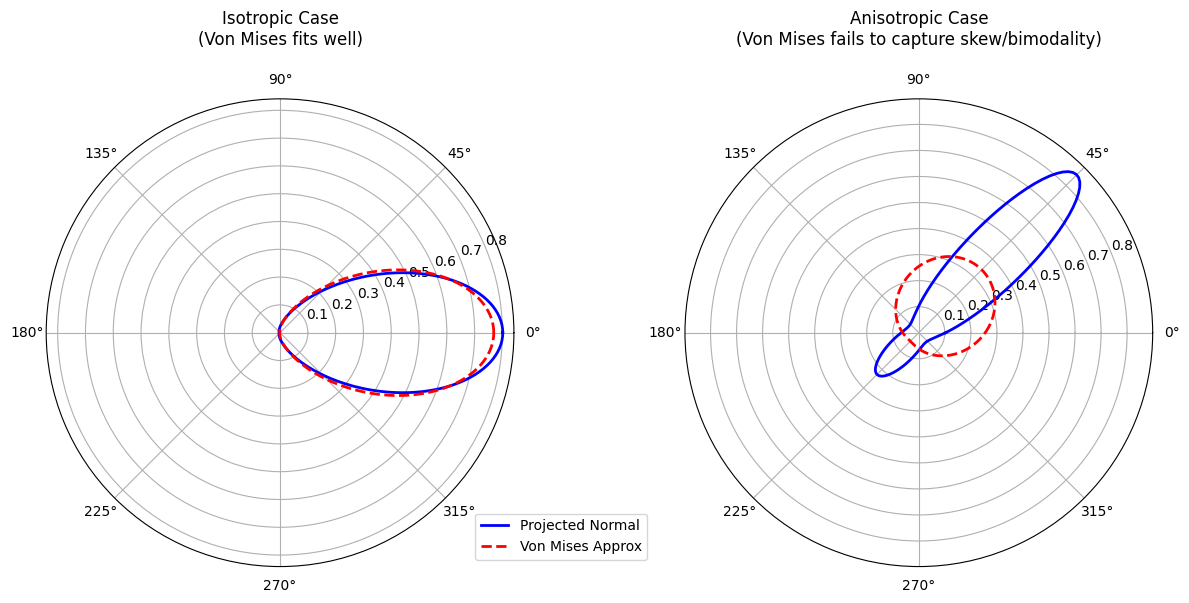

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, multivariate_normal, norm

def projected_normal_pdf(thetas, mean_vec, cov_mat):
    """
    Calculates the PDF of the Projected Normal distribution by integrating
    the 2D Gaussian along rays extending from the origin.
    """
    pdf_vals = []
    
    # Define the 2D Gaussian
    rv = multivariate_normal(mean_vec, cov_mat)
    
    for theta in thetas:
        # Define the unit vector for this angle
        u = np.array([np.cos(theta), np.sin(theta)])
        
        # Numerical integration along the ray r > 0
        # We integrate the 2D Gaussian density f(r*u) * r dr
        # (The extra 'r' comes from the Jacobian of polar coordinates)
        r_vals = np.linspace(0, 10, 500) # Integration limit
        dr = r_vals[1] - r_vals[0]
        
        # Points along the ray
        points = np.outer(r_vals, u) 
        
        # Get 2D density values
        densities = rv.pdf(points)
        
        # Integrate: sum(density * r * dr)
        integral = np.sum(densities * r_vals) * dr
        pdf_vals.append(integral)
        
    return np.array(pdf_vals)

# --- Setup Data ---
theta = np.linspace(0, 2*np.pi, 360)

# Case 1: Isotropic (The "Good" Approximation)
# Mean is far from origin, Covariance is Identity
mu_iso = [2.0, 0.0]
cov_iso = [[1.0, 0.0], [0.0, 1.0]] 
pn_iso = projected_normal_pdf(theta, mu_iso, cov_iso)

# Match Von Mises to this (approx kappa ~= ||mu||^2)
kappa_approx = 2.0**2 
vm_iso = vonmises.pdf(theta, kappa_approx, loc=0)

# Case 2: Anisotropic (The "Failure" Mode)
# Mean is closer to origin, Covariance is stretched
mu_ani = [0.5, 0.5]
cov_ani = [[1.0, 0.8], [0.8, 1.0]] # High correlation creates skew
pn_ani = projected_normal_pdf(theta, mu_ani, cov_ani)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': 'polar'})

# Plot 1: Isotropic Comparison
axes[0].plot(theta, pn_iso, label='Projected Normal', color='blue', linewidth=2)
axes[0].plot(theta, vm_iso, label='Von Mises Approx', color='red', linestyle='--', linewidth=2)
axes[0].set_title("Isotropic Case\n(Von Mises fits well)", pad=20)
axes[0].legend(loc='lower right', bbox_to_anchor=(1.3, 0))

# Plot 2: Anisotropic Comparison
axes[1].plot(theta, pn_ani, label='Projected Normal', color='blue', linewidth=2)
# We fit a VM to the peak of the PN just to show the shape mismatch
vm_fail = vonmises.pdf(theta, 1.0, loc=np.pi/4) 
axes[1].plot(theta, vm_fail, label='Von Mises (Best Effort)', color='red', linestyle='--', linewidth=2)
axes[1].set_title("Anisotropic Case\n(Von Mises fails to capture skew/bimodality)", pad=20)

plt.tight_layout()
plt.show()

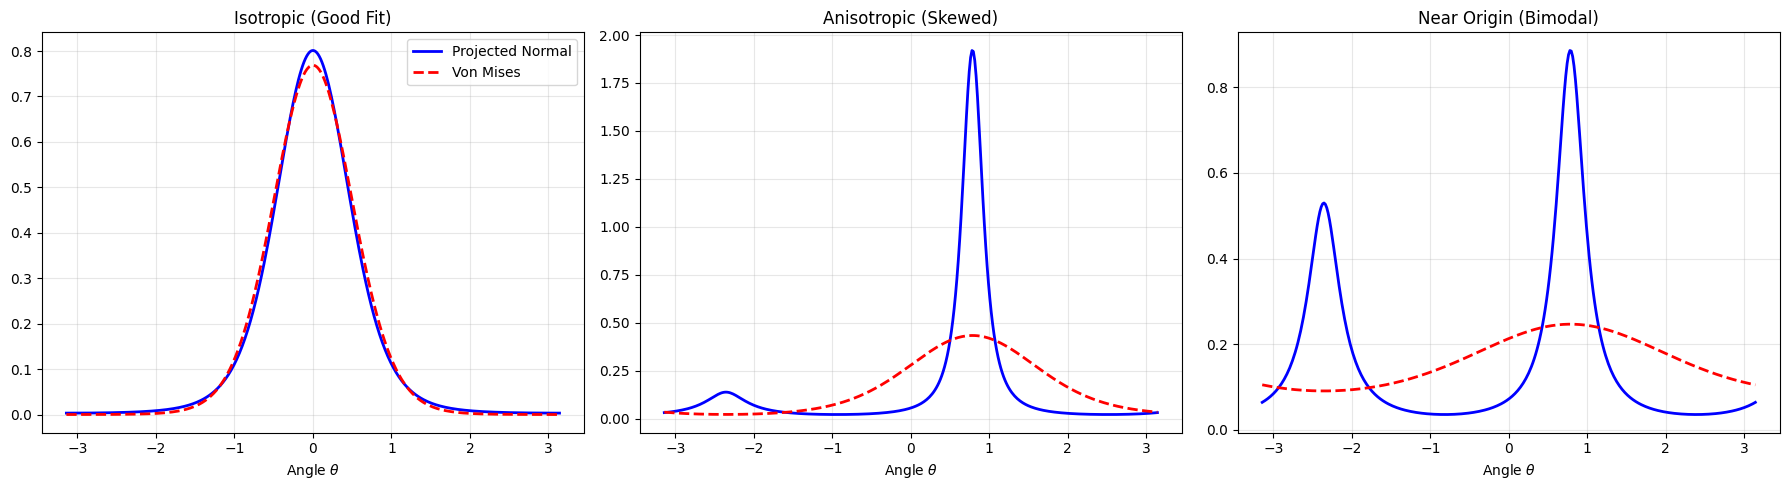

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import vonmises, multivariate_normal

def projected_normal_pdf(thetas, mean_vec, cov_mat):
    """
    Calculates the PDF of the Projected Normal distribution by integrating
    the 2D Gaussian along rays extending from the origin.
    """
    pdf_vals = []
    rv = multivariate_normal(mean_vec, cov_mat)
    
    for theta in thetas:
        u = np.array([np.cos(theta), np.sin(theta)])
        r_vals = np.linspace(0, 10, 500)
        dr = r_vals[1] - r_vals[0]
        densities = rv.pdf(np.outer(r_vals, u))
        integral = np.sum(densities * r_vals) * dr
        pdf_vals.append(integral)
        
    return np.array(pdf_vals)

# --- Setup Data ---
theta = np.linspace(-np.pi, np.pi, 360)

# 1. Isotropic (Symmetric)
mu_iso = [2.0, 0.0]
cov_iso = [[1.0, 0.0], [0.0, 1.0]] 
pn_iso = projected_normal_pdf(theta, mu_iso, cov_iso)
vm_iso = vonmises.pdf(theta, 4.0, loc=0) # kappa approx ||mu||^2

# 2. Anisotropic (Skewed)
mu_ani = [1.0, 1.0] 
cov_ani = [[1.0, 0.9], [0.9, 1.0]] # High correlation creates skew
pn_ani = projected_normal_pdf(theta, mu_ani, cov_ani)
vm_ani = vonmises.pdf(theta, 1.5, loc=np.pi/4)

# 3. Bimodal (Near Origin)
mu_bi = [0.2, 0.2] 
cov_bi = [[1.0, 0.9], [0.9, 1.0]] 
pn_bi = projected_normal_pdf(theta, mu_bi, cov_bi)
vm_bi = vonmises.pdf(theta, 0.5, loc=np.pi/4)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Isotropic (Good Fit)', 'Anisotropic (Skewed)', 'Near Origin (Bimodal)']
data_pn = [pn_iso, pn_ani, pn_bi]
data_vm = [vm_iso, vm_ani, vm_bi]

for i in range(3):
    axes[i].plot(theta, data_pn[i], label='Projected Normal', color='blue', linewidth=2)
    axes[i].plot(theta, data_vm[i], label='Von Mises', color='red', linestyle='--', linewidth=2)
    axes[i].set_title(labels[i])
    axes[i].set_xlabel(r"Angle $\theta$")
    axes[i].grid(True, alpha=0.3)
    if i == 0: axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Minimum value of the projected normal PDF
min_pn_value = np.min(pn_bi)
print(f"Minimum value of the projected normal PDF (bimodal case): {min_pn_value}")

# Analytical insight:
# The projected normal distribution can exhibit bimodality when the mean vector is close to the origin
# and the covariance matrix is anisotropic (highly correlated). This leads to two preferred directions
# in the angular distribution, which Von Mises cannot capture due to its unimodal nature.   
#!/usr/bin/env python3
# --- IGNORE ---

Minimum value of the projected normal PDF (bimodal case): 0.03570729778519661


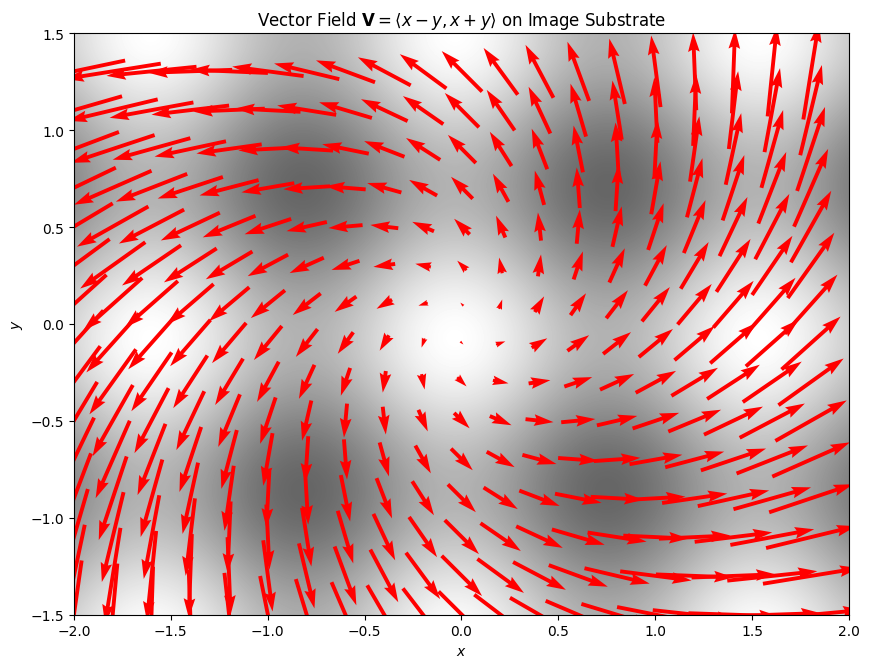

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Generate a dummy image (or load yours using mpimg.imread('path.png'))
H, W = 600, 800
# Creating a synthetic background (e.g., a gradient) to act as our "Image"
y_indices, x_indices = np.mgrid[0:H, 0:W]
image = np.sin(x_indices / 50) + np.cos(y_indices / 50)

# 2. Define the Physical Coordinate System
# Let's map the image to a physical rectangle [-2, 2] x [-1.5, 1.5]
x_min, x_max = -2, 2
y_min, y_max = -1.5, 1.5

# Create a meshgrid for the vector field evaluation
# Note: We use 'xy' indexing so X corresponds to columns and Y to rows
X_mesh = np.linspace(x_min, x_max, W)
Y_mesh = np.linspace(y_min, y_max, H)
X, Y = np.meshgrid(X_mesh, Y_mesh)

# 3. Define the Vector Field V(x, y)
# Example: A saddle point V = (x, -y) or a spiral V = (x - y, x + y)
# Let's do a Spiral Source:
U = X - Y   # x-component of the vector
V = X + Y   # y-component of the vector

# 4. Subsampling (Crucial Step)
# Plotting a vector at every single pixel creates a solid black block. 
# We must slice the arrays to plot every Nth vector.
N = 40 # Skip every 40 pixels
slice_y = slice(None, None, N) # slice(start, stop, step)
slice_x = slice(None, None, N)

X_sub = X[slice_y, slice_x]
Y_sub = Y[slice_y, slice_x]
U_sub = U[slice_y, slice_x]
V_sub = V[slice_y, slice_x]

# 5. Plotting with Rigorous Alignment
fig, ax = plt.subplots(figsize=(10, 8))

# A. Show the image
# 'extent' maps the pixel grid to your physical coordinates [left, right, bottom, top]
# 'origin' ensures the (0,0) of the array is at the top-left visual position
ax.imshow(image, cmap='gray', extent=[x_min, x_max, y_min, y_max], origin='upper', alpha=0.6)

# B. Plot the vectors
# We overlay the quiver plot on top.
# pivot='mid' centers the arrow on the grid point.
ax.quiver(X_sub, Y_sub, U_sub, V_sub, color='red', scale=25, width=0.005, pivot='mid')

ax.set_title(r"Vector Field $\mathbf{V} = \langle x-y, x+y \rangle$ on Image Substrate")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_aspect('equal') # Essential to prevent distortion of the vector angles
plt.show()